## I Dewa Putu Aditya Rahman
### 2106650456


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy import polyfit
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import precision_score, \
    recall_score, classification_report, \
    accuracy_score, f1_score, \
    mean_absolute_error, mean_squared_error, \
    root_mean_squared_error, r2_score, mean_absolute_percentage_error,\
    silhouette_score
from sklearn.impute import KNNImputer, SimpleImputer
from imblearn.over_sampling import ADASYN
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer


In [81]:
csl_df = pd.read_csv('train_csl.csv')
display(csl_df.head())
display(csl_df.info())
display(csl_df.describe())

,user_age_group,user_id,attempt_date,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,25 to 34,1972,2017-12-22,male,712,15.8,382,Headquarters Business Park,54 kg and under,Night Ride,13.6,34.9,19.24,5103,5103,0,6977
1,25 to 34,239,2015-04-13,male,189,33.2,216,Oghor 2 SailsIsland,105 kg to 114 kg,Night Ride,21.5,43.2,23.47,3926,3926,0,3518
2,25 to 34,405,2018-02-07,male,264,23.7,593,Starbucks to Majid,75 to 84 kg,Evening Ride,26.7,92.9,38.23,5152,5152,0,415
3,25 to 34,318,2018-08-24,male,50,33.4,817,Al Fardoos to shellfish round about,75 to 84 kg,Afternoon Ride,31.4,54.4,65.77,7548,7548,1,1755
4,25 to 34,628,2020-03-06,female,19,21.3,284,Headquarters Business Park,54 kg and under,ثاني تمرين ١٠٠كم,19.9,43.2,96.53,17493,17493,0,7088


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6292 entries, 0 to 6291
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        6292 non-null   object 
 1   user_id               6292 non-null   int64  
 2   attempt_date          6292 non-null   object 
 3   gender                6292 non-null   object 
 4   smt_rank              6292 non-null   int64  
 5   smt_avg_spd           6292 non-null   float64
 6   smt_finish_seconds    6292 non-null   int64  
 7   smt_name              6292 non-null   object 
 8   user_weight_category  5932 non-null   object 
 9   act_title             6292 non-null   object 
 10  act_avg_spd           6292 non-null   float64
 11  act_max_spd           6292 non-null   float64
 12  act_total_km          6292 non-null   float64
 13  act_moving_seconds    6292 non-null   int64  
 14  act_total_seconds     6292 non-null   int64  
 15  has_hr_data          

None

,user_id,smt_rank,smt_avg_spd,smt_finish_seconds,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
count,6292.000000,6292.000000,6292.00000,6292.000000,6292.000000,6292.000000,6292.000000,6.292000e+03,6.292000e+03,6292.000000,6292.000000
mean,782.421964,172.515893,26.80925,531.276224,22.681024,44.757533,42.147134,1.252379e+04,1.252379e+04,0.196440,3947.028608
std,539.051866,173.487689,8.44806,431.974886,5.851547,17.055338,27.010789,2.157781e+05,2.157781e+05,0.397337,2261.820409
min,2.000000,1.000000,0.80000,112.000000,0.000000,8.600000,2.280000,2.640000e+02,2.640000e+02,0.000000,1.000000
25%,335.000000,37.000000,21.30000,266.000000,18.700000,36.700000,23.440000,4.095000e+03,4.095000e+03,0.000000,2004.750000
50%,703.500000,108.000000,26.50000,439.000000,22.100000,42.100000,37.780000,5.781500e+03,5.781500e+03,0.000000,3941.000000
75%,1096.000000,267.000000,32.50000,651.000000,26.400000,48.600000,52.140000,8.098500e+03,8.098500e+03,0.000000,5907.250000
max,2254.000000,805.000000,87.30000,9224.000000,75.200000,690.800000,706.590000,1.167978e+07,1.167978e+07,1.000000,7863.000000


In [82]:
csl_df = csl_df.drop(['id', 'user_id'], axis=1)

# Classification : Determining Gender

### 1. Split dataset to prevent data contamination/leakage

In [83]:
x = csl_df.drop(['gender'], axis=1)
y = csl_df['gender']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=6969)

# Merge feature and target for preprocessing
cla_train = pd.concat([x_train, y_train], axis=1)
cla_train.shape

(5033, 15)

### 2. Data preprocessing

#### 2a. Handling outliers

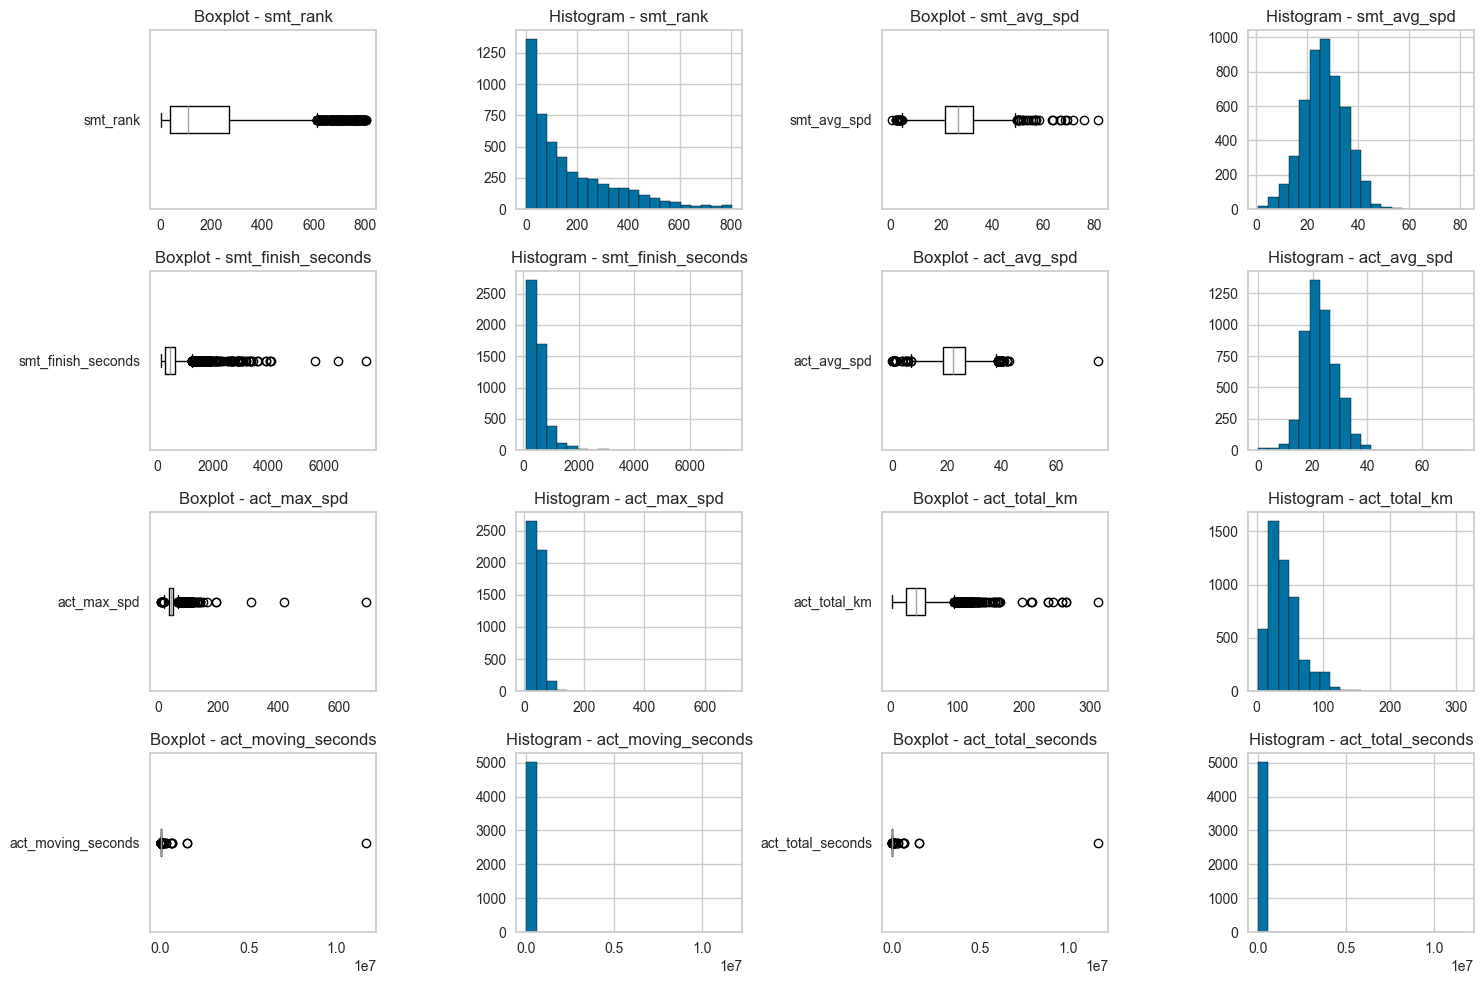

In [84]:
def show_stats(df):
    numeric_cols = df.select_dtypes(include=np.number).columns

    n_features = len(numeric_cols)
    n_cols = 4
    n_rows = (n_features * 2 + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
    axes = axes.ravel()

    for i, col in enumerate(numeric_cols):
        df[[col]].boxplot(ax=axes[2 * i], grid=False, vert=False)
        axes[2 * i].set_title(f'Boxplot - {col}')
        
        df[col].hist(ax=axes[2 * i + 1], bins=20, edgecolor='black')
        axes[2 * i + 1].set_title(f'Histogram - {col}')

    for j in range(2 * n_features, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

show_stats(cla_train.drop(['has_hr_data'], axis=1))

Metode saya adalah memotong (menghilangkan) outlier ekstrim dan menyimpan outlier yang tidak terlalu ekstrim, karena:
1. Outlier ekstrim saya anggap suatu kesalahan input atau sesuatu yang sangat jarang sekali terjadi. Contoh: data act_max_spd mencapai lebih dari 600 km/j, hal ini bisa menandakan kesalahan data atau seseorang yang lupa untuk menyelesaikan "aktivitas" sehingga saat orang tersebut menaiki pesawat akan terdata kecepatannya.

2. Outlier biasa saya simpan karena dapat menandakan seseorang yang sangat mahir dalam bersepeda, hal tersebut dapat mempengaruhi keputusan model. Dan juga karena random forest tidak dipengaruhi outlier.

In [85]:
def remove(df, low_lim, high_lim):
    col = df.select_dtypes(include=np.number).columns

    lower_limit = df[col].quantile(low_lim)
    upper_limit = df[col].quantile(high_lim)

    df_no_outlier = df[(df[col] >= lower_limit).all(axis=1) & (df[col] <= upper_limit).all(axis=1)]

    return df_no_outlier

cla_train = remove(cla_train, 0.01, 0.99)
cla_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4601 entries, 5710 to 607
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        4601 non-null   object 
 1   attempt_date          4601 non-null   object 
 2   smt_rank              4601 non-null   int64  
 3   smt_avg_spd           4601 non-null   float64
 4   smt_finish_seconds    4601 non-null   int64  
 5   smt_name              4601 non-null   object 
 6   user_weight_category  4375 non-null   object 
 7   act_title             4601 non-null   object 
 8   act_avg_spd           4601 non-null   float64
 9   act_max_spd           4601 non-null   float64
 10  act_total_km          4601 non-null   float64
 11  act_moving_seconds    4601 non-null   int64  
 12  act_total_seconds     4601 non-null   int64  
 13  has_hr_data           4601 non-null   int64  
 14  gender                4601 non-null   object 
dtypes: float64(4), int64(5),

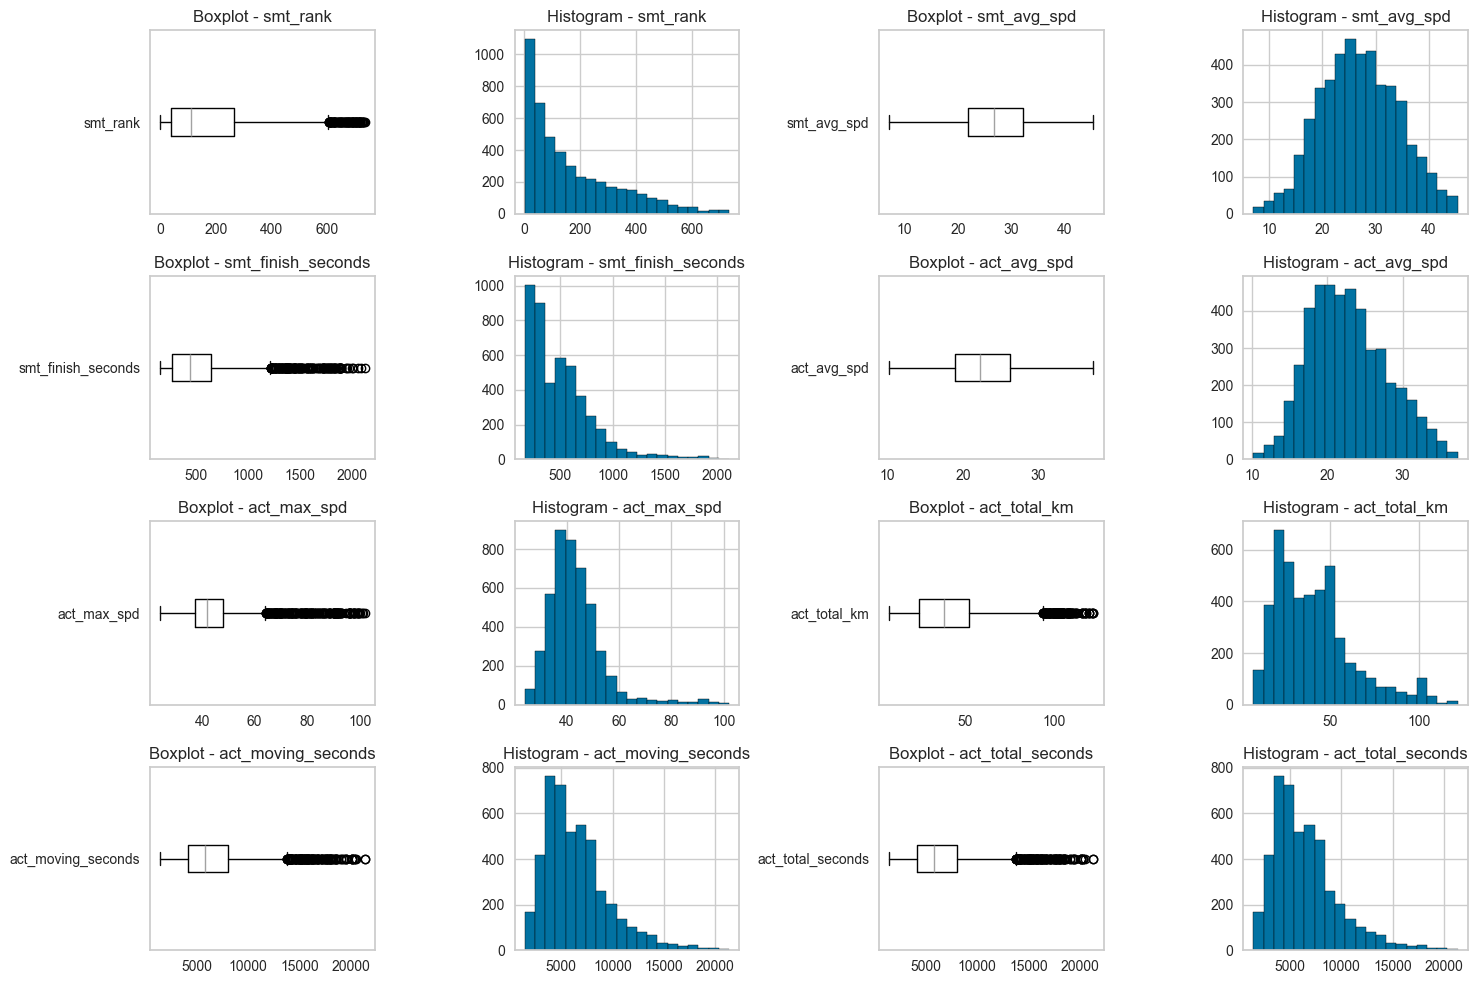

In [86]:
show_stats(cla_train.drop(['has_hr_data'], axis=1))

#### 2b. Handling missing data

In [87]:
cla_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4601 entries, 5710 to 607
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        4601 non-null   object 
 1   attempt_date          4601 non-null   object 
 2   smt_rank              4601 non-null   int64  
 3   smt_avg_spd           4601 non-null   float64
 4   smt_finish_seconds    4601 non-null   int64  
 5   smt_name              4601 non-null   object 
 6   user_weight_category  4375 non-null   object 
 7   act_title             4601 non-null   object 
 8   act_avg_spd           4601 non-null   float64
 9   act_max_spd           4601 non-null   float64
 10  act_total_km          4601 non-null   float64
 11  act_moving_seconds    4601 non-null   int64  
 12  act_total_seconds     4601 non-null   int64  
 13  has_hr_data           4601 non-null   int64  
 14  gender                4601 non-null   object 
dtypes: float64(4), int64(5),

Hanya terdapat missing data pada user_weight_category yang merupakan data kategorik (karena jumlah non_null tidak sama dengan total data). Metode saya adalah untuk menggunakan simple imputer untuk megisi missing data dengan mode. 

In [88]:
x_train = cla_train.drop(['gender'], axis=1)
y_train = cla_train['gender']

numeric_columns = x_train.select_dtypes(include=np.number).columns
cla_imputer = SimpleImputer(strategy='most_frequent')
x_train = cla_imputer.fit_transform(x_train)

# Convert from array back to dataframe
x_train = pd.DataFrame(x_train, columns=cla_imputer.get_feature_names_out())
for col in numeric_columns:
    x_train[col] = x_train[col].convert_dtypes()

#### 2c. Handling categorical data

In [89]:
def explain_categoric(df):
    for col in df.select_dtypes(include=object).columns:
        display(df[col].value_counts())

explain_categoric(x_train)

user_age_group
25 to 34        2003
35 to 44        1352
45 to 54         500
20 to 24         395
19 and under     219
55 to 64         106
75+               14
65 to 69          11
70 to 74           1
Name: count, dtype: int64

attempt_date
2019-04-27    21
2019-01-26    21
2018-01-03    21
2019-11-20    20
2019-04-19    19
              ..
2014-12-10     1
2013-06-27     1
2016-06-10     1
2015-01-05     1
2016-12-17     1
Name: count, Length: 1324, dtype: int64

smt_name
Headquarters Business Park                    1044
Oghor 2 SailsIsland                            939
North Corniche                                 798
Starbucks to Majid                             661
King Street side                               454
PRINCE SULTAN - ASSALAM TO FATIMA              262
S.Ubhur Alkurnaysh South Bound with detour     190
Obhur North Short                              128
Al Fardoos to shellfish round about            125
Name: count, dtype: int64

user_weight_category
54 kg and under     1687
75 to 84 kg          855
85 to 95 kg          633
65 to 74 kg          584
95 kg to 104 kg      319
55 to 64 kg          210
105 kg to 114 kg     183
115 kg and over      130
Name: count, dtype: int64

act_title
Evening Ride                                           1331
Morning Ride                                           1078
Night Ride                                              594
Afternoon Ride                                          396
Lunch Ride                                               18
                                                       ... 
Evening Ride at Corniche Road with strong winds           1
مسار جديد                                                 1
 تمسيكية جدا جميلة مع جدة سايكلست fire man biking         1
تمرين خفيف جداً recycling symbol check mark button        1
تمرين مع احلى شباب                                        1
Name: count, Length: 824, dtype: int64

Metode saya untuk menangani data kategorik adalah:
1. Mengubah data ordinal dan binary secara manual agar sesuai dengan keinginan, yakni user_age_group, user_weight_category, dan gender
2. Mengubah data tanggal menjadi data hari dalam minggu (0 = Senin, 6 = Minggu), yakni attempt_date
3. Mengubah data nominal yang tidak terlalu banyak label dengan one-hot encoding, yakni smt_name
4. Menghilangkan data nominal yang terlalu banyak label, yakni act_title

In [90]:
x_train = x_train.drop(['act_title'], axis=1)

In [91]:
age_group_mapping = {
    "19 and under"    :1,
    "20 to 24"        :2,
    "25 to 34"        :3,
    "35 to 44"        :4,
    "45 to 54"        :5,
    "55 to 64"        :6,
    "65 to 69"        :7,
    "70 to 74"        :8,
    "75+"             :9
}
weight_group_mapping = {
    "54 kg and under"    :1,
    "55 to 64 kg"        :2,
    "65 to 74 kg"        :3,
    "75 to 84 kg"        :4,
    "85 to 95 kg"        :5,
    "95 kg to 104 kg"    :6,
    "105 kg to 114 kg"   :7,
    "115 kg and over"    :8
}
x_train.loc[:,'user_age_group'] = x_train['user_age_group'].map(age_group_mapping)
x_train.loc[:,'user_weight_category'] = x_train['user_weight_category'].map(weight_group_mapping)

In [92]:
x_train.loc[:, 'attempt_date'] = pd.to_datetime(x_train['attempt_date'], errors="raise").dt.dayofweek

In [93]:
for col in ['user_weight_category', 'user_age_group', 'attempt_date']:
    x_train[col] = pd.to_numeric(x_train[col], errors="raise")
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        4601 non-null   int64  
 1   attempt_date          4601 non-null   int64  
 2   smt_rank              4601 non-null   Int64  
 3   smt_avg_spd           4601 non-null   Float64
 4   smt_finish_seconds    4601 non-null   Int64  
 5   smt_name              4601 non-null   object 
 6   user_weight_category  4601 non-null   int64  
 7   act_avg_spd           4601 non-null   Float64
 8   act_max_spd           4601 non-null   Float64
 9   act_total_km          4601 non-null   Float64
 10  act_moving_seconds    4601 non-null   Int64  
 11  act_total_seconds     4601 non-null   Int64  
 12  has_hr_data           4601 non-null   Int64  
dtypes: Float64(4), Int64(5), int64(3), object(1)
memory usage: 507.9+ KB


In [94]:
x_train = pd.get_dummies(x_train)
x_train = x_train.astype('float32')

#### 2d. Handling data imbalance

In [95]:
y_train.value_counts()

gender
male      4444
female     157
Name: count, dtype: int64

Metode saya adalah menggunakan ADASYN untuk oversample kelas minoritas.

In [96]:
cla_adasyn = ADASYN(sampling_strategy='minority')
x_train, y_train = cla_adasyn.fit_resample(x_train, y_train)
print(y_train.value_counts())

gender
male      4444
female    4405
Name: count, dtype: int64


### 3. Model

In [97]:
cla_model = RandomForestClassifier(random_state=6969)
cla_model.fit(x_train, y_train)

RandomForestClassifier(random_state=6969)

### 4. Model Evaluation

#### 4a. Mempersiapkan data testing

In [98]:
display(x_test.head())
display(y_test.head())

,user_age_group,attempt_date,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
2108,20 to 24,2014-12-22,98,21.5,281,Headquarters Business Park,54 kg and under,Evening Ride,21.0,37.8,15.91,2729,2729,0
782,35 to 44,2019-02-22,71,9.4,2629,Obhur North Short,NaN,Morning Ride,19.3,36.7,96.30,18000,18000,0
6269,35 to 44,2016-10-24,127,26.5,532,Starbucks to Majid,115 kg and over,Evening Ride,18.4,41.4,18.65,3649,3649,0
3674,25 to 34,2018-10-03,99,29.3,206,Headquarters Business Park,65 to 74 kg,Evening Ride,4.1,81.4,112.15,98816,98816,0
4090,25 to 34,2015-11-18,531,11.2,1554,North Corniche,115 kg and over,Evening Ride,16.8,28.8,18.57,3991,3991,0


2108    male
782     male
6269    male
3674    male
4090    male
Name: gender, dtype: object

In [99]:
numeric_columns = x_test.select_dtypes(include=np.number).columns
x_test = cla_imputer.transform(x_test)

# Convert from array back to dataframe
x_test = pd.DataFrame(x_test, columns=cla_imputer.get_feature_names_out())
for col in numeric_columns:
    x_test[col] = x_test[col].convert_dtypes()

In [100]:
x_test.loc[:,'user_age_group'] = x_test['user_age_group'].map(age_group_mapping)
x_test.loc[:,'user_weight_category'] = x_test['user_weight_category'].map(weight_group_mapping)

x_test = x_test.drop(['act_title'], axis=1)

x_test.loc[:, 'attempt_date'] = pd.to_datetime(x_test['attempt_date'], errors="raise").dt.dayofweek

for col in ['user_weight_category', 'user_age_group', 'attempt_date']:
    x_test[col] = pd.to_numeric(x_test[col], errors="raise")

x_test = pd.get_dummies(x_test)
x_test = x_test.astype('float32')

#### 4b. Prediksi data testing

In [101]:
y_pred = cla_model.predict(x_test)

def evaluate_classifier_performance(prediction, y_test):
    # Informasi evaluasi secara compact
    print("Hasil Evaluasi berdasarkan classification report \n\n%s\n" % (classification_report(y_test, prediction,zero_division=0)))
    print()
    print("Confusion Matrix")
    print()
    y_actual = pd.Series(np.array(y_test), name = "actual")
    y_pred = pd.Series(np.array(prediction), name = "prediction")
    df_confusion = pd.crosstab(y_actual, y_pred)
    display(df_confusion)
    print()
    print()

    print("Butuh informasi lebih lengkap? silakan simak di bawah ini : ")
    print('Accuracy Average:', accuracy_score(y_test, prediction))
    print('F1 Macro Average:', f1_score(y_test, prediction, average='macro'))
    print('F1 Micro Average:', f1_score(y_test, prediction, average='micro'))
    print('Precision Macro Average:', precision_score(y_test, prediction, average='macro',zero_division=0))
    print('Precision Micro Average:', precision_score(y_test, prediction, average='micro',zero_division=0))
    print('Recall Macro Average:', recall_score(y_test, prediction, average='macro',zero_division=0))
    print('Recall Micro Average:', recall_score(y_test, prediction, average='micro',zero_division=0))
    print()

print('Model - Random Forest')
evaluate_classifier_performance(y_pred, y_test)


Model - Random Forest
Hasil Evaluasi berdasarkan classification report 

              precision    recall  f1-score   support

      female       0.98      0.89      0.93        63
        male       0.99      1.00      1.00      1196

    accuracy                           0.99      1259
   macro avg       0.99      0.94      0.96      1259
weighted avg       0.99      0.99      0.99      1259



Confusion Matrix



prediction,female,male
actual,,
female,56,7
male,1,1195




Butuh informasi lebih lengkap? silakan simak di bawah ini : 
Accuracy Average: 0.9936457505957109
F1 Macro Average: 0.9649986099527383
F1 Micro Average: 0.9936457505957109
Precision Macro Average: 0.9883162565315118
Precision Micro Average: 0.9936457505957109
Recall Macro Average: 0.9440263842437755
Recall Micro Average: 0.9936457505957109



# Regression : Calculating Finish Time in Segment (Seconds)

### 1. Split dataset to prevent data contamination/leakage

In [102]:
x = csl_df.drop(['smt_finish_seconds'], axis=1)
y = csl_df['smt_finish_seconds']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=420)

# Merge feature and target for preprocessing
reg_train = pd.concat([x_train, y_train], axis=1)
reg_train.shape

(5033, 15)

### 2. Data preprocessing

#### 2a. Handling outliers

In [103]:
reg_train = remove(reg_train, 0.01, 0.99)
reg_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4600 entries, 5492 to 2993
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        4600 non-null   object 
 1   attempt_date          4600 non-null   object 
 2   gender                4600 non-null   object 
 3   smt_rank              4600 non-null   int64  
 4   smt_avg_spd           4600 non-null   float64
 5   smt_name              4600 non-null   object 
 6   user_weight_category  4358 non-null   object 
 7   act_title             4600 non-null   object 
 8   act_avg_spd           4600 non-null   float64
 9   act_max_spd           4600 non-null   float64
 10  act_total_km          4600 non-null   float64
 11  act_moving_seconds    4600 non-null   int64  
 12  act_total_seconds     4600 non-null   int64  
 13  has_hr_data           4600 non-null   int64  
 14  smt_finish_seconds    4600 non-null   int64  
dtypes: float64(4), int64(5)

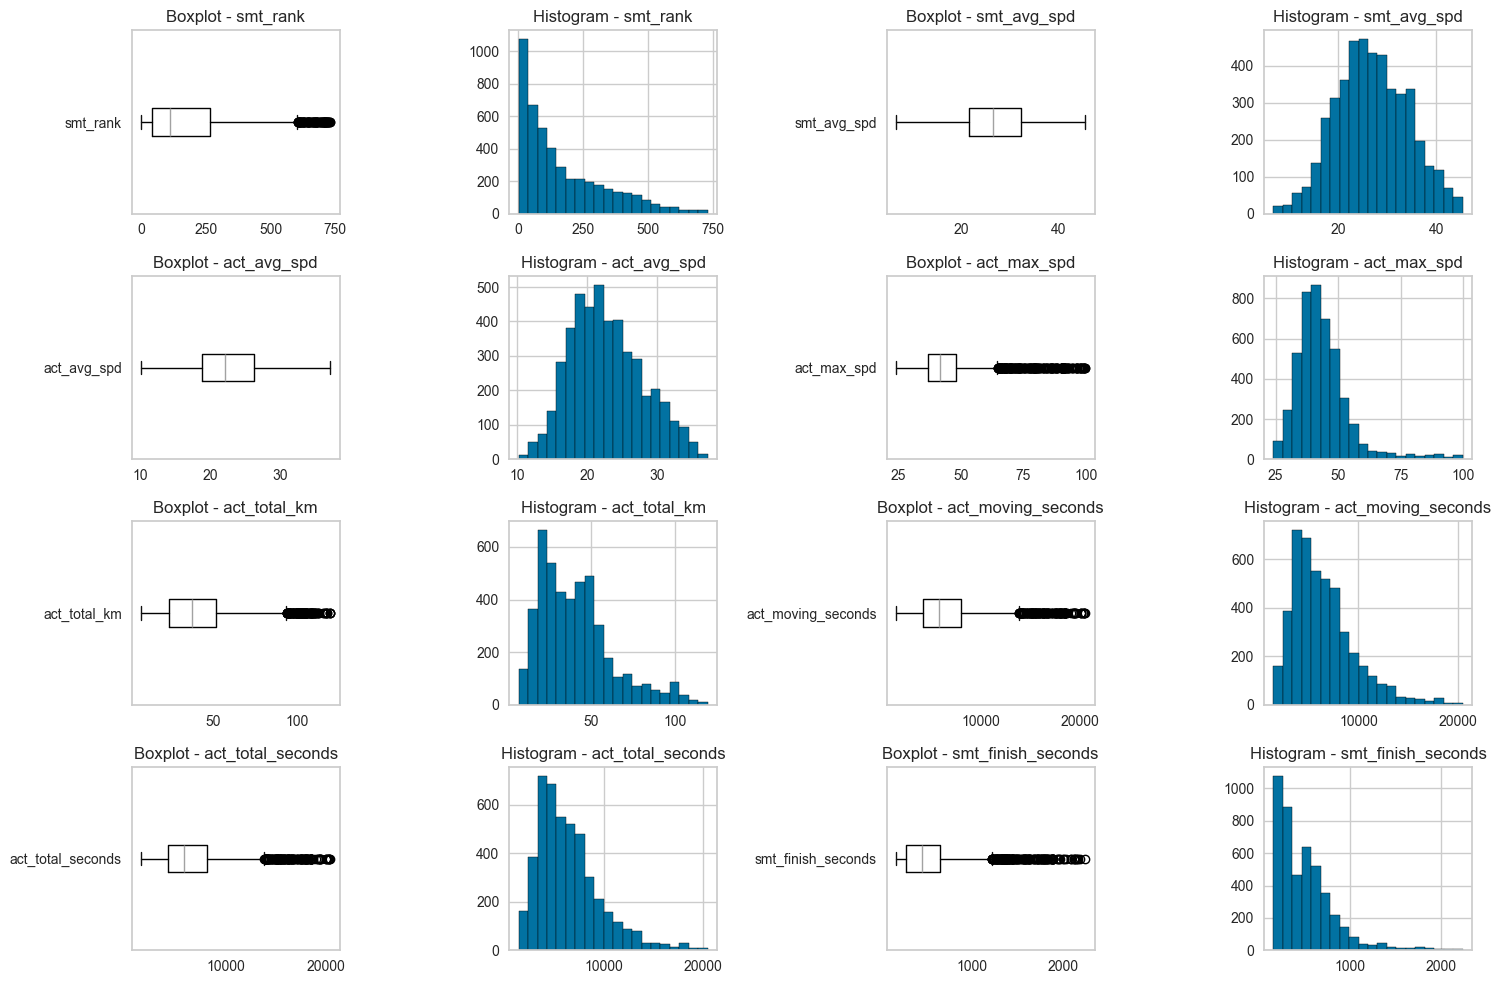

In [104]:
show_stats(reg_train.drop(['has_hr_data'], axis=1))

#### 2b. Handling missing data

In [105]:
x_train = reg_train.drop(['smt_finish_seconds'], axis=1)
y_train = reg_train['smt_finish_seconds']

numeric_columns = x_train.select_dtypes(include=np.number).columns
display(x_train.info())
reg_imputer = SimpleImputer(strategy='most_frequent')
x_train = reg_imputer.fit_transform(x_train)

# Convert from array back to dataframe
x_train = pd.DataFrame(x_train, columns=reg_imputer.get_feature_names_out())
for col in numeric_columns:
    x_train[col] = x_train[col].convert_dtypes()

<class 'pandas.core.frame.DataFrame'>
Index: 4600 entries, 5492 to 2993
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        4600 non-null   object 
 1   attempt_date          4600 non-null   object 
 2   gender                4600 non-null   object 
 3   smt_rank              4600 non-null   int64  
 4   smt_avg_spd           4600 non-null   float64
 5   smt_name              4600 non-null   object 
 6   user_weight_category  4358 non-null   object 
 7   act_title             4600 non-null   object 
 8   act_avg_spd           4600 non-null   float64
 9   act_max_spd           4600 non-null   float64
 10  act_total_km          4600 non-null   float64
 11  act_moving_seconds    4600 non-null   int64  
 12  act_total_seconds     4600 non-null   int64  
 13  has_hr_data           4600 non-null   int64  
dtypes: float64(4), int64(4), object(6)
memory usage: 539.1+ KB


None

#### 2c. Handling categorical data

In [106]:
x_train = x_train.drop(['act_title'], axis=1)

gender_mapping = {
    "male" : 1,
    "female" : 2
}
x_train.loc[:,'user_age_group'] = x_train['user_age_group'].map(age_group_mapping)
x_train.loc[:,'user_weight_category'] = x_train['user_weight_category'].map(weight_group_mapping)
x_train.loc[:,'gender'] = x_train['gender'].map(gender_mapping)

x_train.loc[:, 'attempt_date'] = pd.to_datetime(x_train['attempt_date'], errors="raise").dt.dayofweek

for col in ['user_weight_category', 'gender', 'user_age_group', 'attempt_date']:
    x_train[col] = pd.to_numeric(x_train[col], errors="raise")

x_train = pd.get_dummies(x_train)
x_train = x_train.astype('float32')

### 3. Model

In [107]:
model = RandomForestRegressor(random_state=420)
# reg_model.fit(x_train, y_train)

params = [{
    # 'max_depth': [5, 6, 7, 8],
    'n_estimators': [100, 150],
    'min_samples_split': [4, 6]
}]

kfold = KFold(n_splits=5, shuffle=True)

reg_model = GridSearchCV(
    model, 
    params, 
    scoring='r2',
    cv=kfold
)

reg_model.fit(x_train, y_train)
print(reg_model.best_params_)

{'min_samples_split': 4, 'n_estimators': 150}


### 4. Model Evaluation

#### 4a. Mempersiapkan data testing

In [108]:
display(x_test.head())
display(y_test.head())

,user_age_group,attempt_date,gender,smt_rank,smt_avg_spd,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
571,19 and under,2018-02-07,male,46,21.6,North Corniche,75 to 84 kg,كورنيش ١,19.4,36.0,17.34,3223,3223,0
4766,25 to 34,2018-11-28,male,298,24.0,Headquarters Business Park,54 kg and under,Night Ride,18.1,40.3,24.31,4827,4827,0
4393,45 to 54,2019-01-14,male,36,30.8,PRINCE SULTAN - ASSALAM TO FATIMA,54 kg and under,الأمل زاد الحياة,28.2,41.0,43.26,5524,5524,0
794,20 to 24,2017-08-09,male,92,22.2,Headquarters Business Park,75 to 84 kg,تمرين دراج جده,21.4,45.4,24.63,4148,4148,0
2206,25 to 34,2019-03-29,male,348,28.0,Oghor 2 SailsIsland,65 to 74 kg,Afternoon Ride,19.8,39.6,26.54,4838,4838,0


571     803
4766    252
4393    317
794     272
2206    256
Name: smt_finish_seconds, dtype: int64

In [109]:
numeric_columns = x_test.select_dtypes(include=np.number).columns
display(x_test.info())
x_test = reg_imputer.transform(x_test)

# Convert from array back to dataframe
x_test = pd.DataFrame(x_test, columns=reg_imputer.get_feature_names_out())
for col in numeric_columns:
    x_test[col] = x_test[col].convert_dtypes()

x_test.loc[:,'user_age_group'] = x_test['user_age_group'].map(age_group_mapping)
x_test.loc[:,'user_weight_category'] = x_test['user_weight_category'].map(weight_group_mapping)
x_test.loc[:,'gender'] = x_test['gender'].map(gender_mapping)

x_test = x_test.drop(['act_title'], axis=1)

x_test.loc[:, 'attempt_date'] = pd.to_datetime(x_test['attempt_date'], errors="raise").dt.dayofweek

for col in ['user_weight_category', 'gender', 'user_age_group', 'attempt_date']:
    x_test[col] = pd.to_numeric(x_test[col], errors="raise")

x_test = pd.get_dummies(x_test)
x_test = x_test.astype('float32')

<class 'pandas.core.frame.DataFrame'>
Index: 1259 entries, 571 to 4691
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        1259 non-null   object 
 1   attempt_date          1259 non-null   object 
 2   gender                1259 non-null   object 
 3   smt_rank              1259 non-null   int64  
 4   smt_avg_spd           1259 non-null   float64
 5   smt_name              1259 non-null   object 
 6   user_weight_category  1190 non-null   object 
 7   act_title             1259 non-null   object 
 8   act_avg_spd           1259 non-null   float64
 9   act_max_spd           1259 non-null   float64
 10  act_total_km          1259 non-null   float64
 11  act_moving_seconds    1259 non-null   int64  
 12  act_total_seconds     1259 non-null   int64  
 13  has_hr_data           1259 non-null   int64  
dtypes: float64(4), int64(4), object(6)
memory usage: 147.5+ KB


None

#### 4b. Prediksi data testing

In [110]:
y_pred = reg_model.predict(x_test)

def evaluate_regressor_performance(y_pred, y_test):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    r2 = r2_score(y_test, y_pred)
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Percentage (MAPE): {mape:.4f} %")
    print(f"R² Score: {r2:.4f}")

print("Model - Random Forest\n")
evaluate_regressor_performance(y_pred, y_test)

Model - Random Forest

Mean Absolute Error (MAE): 16.3850
Mean Squared Error (MSE): 48108.1224
Root Mean Squared Error (RMSE): 219.3356
Mean Absolute Percentage (MAPE): 1.1462 %
R² Score: 0.7267


# Clustering : its cluster time

### 1. Data preprocessing

#### 1a. Handling Outliers

In [111]:
clu_df = csl_df.copy()
print(clu_df.shape)

(6292, 15)


(5760, 15)


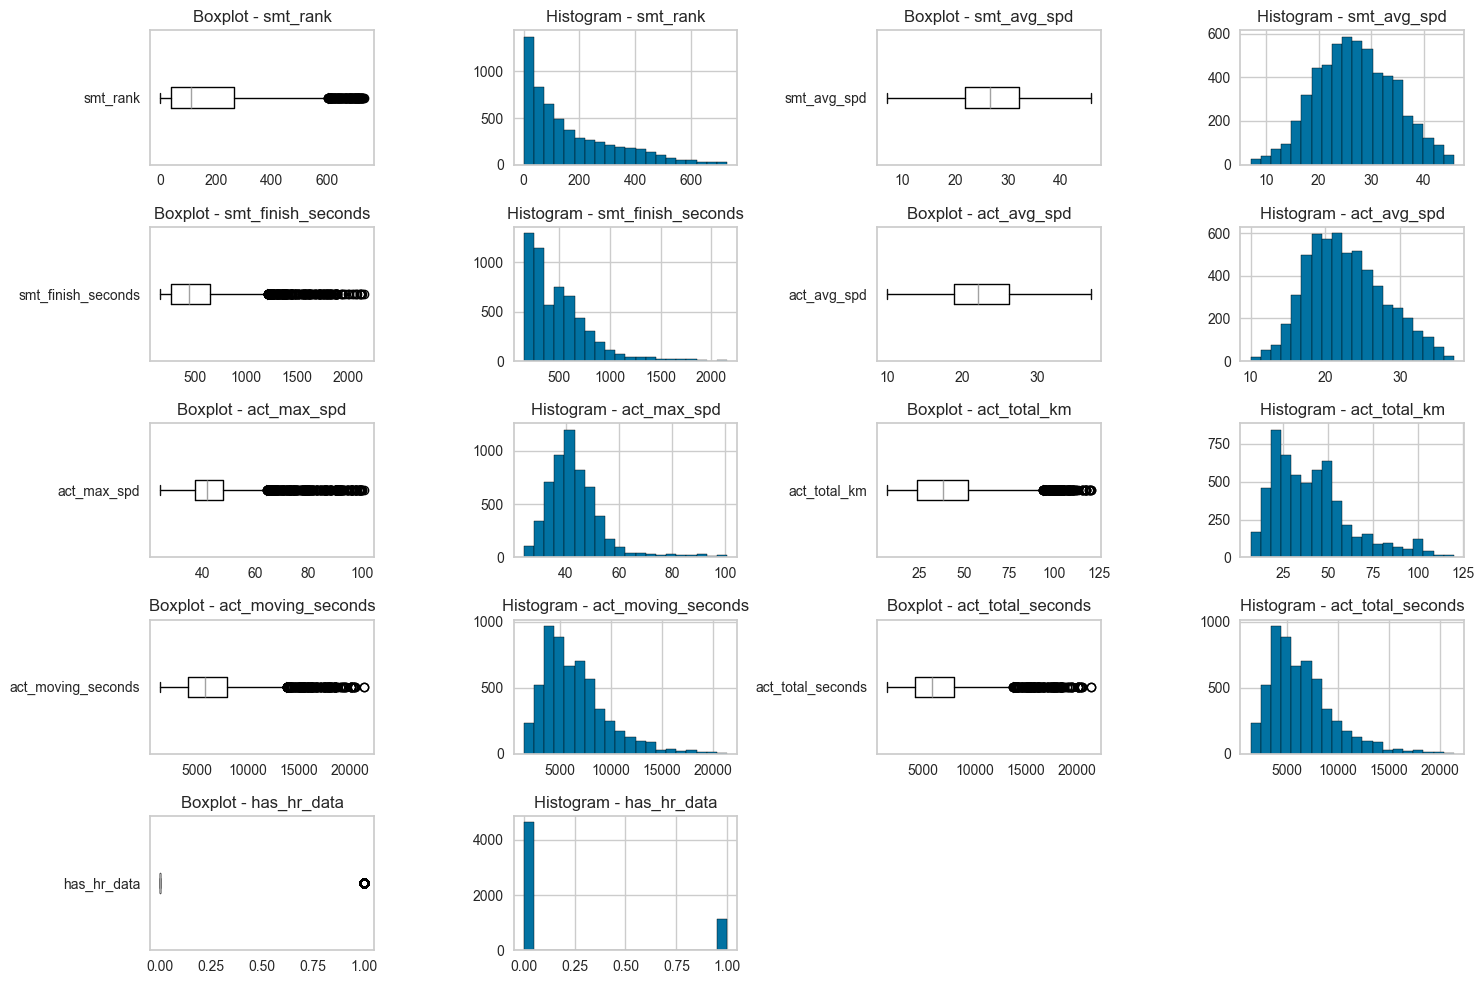

In [112]:
clu_df = remove(clu_df, 0.01, 0.99)
print(clu_df.shape)
show_stats(clu_df)

#### 1b. Handling missing data

In [113]:
numeric_columns = clu_df.select_dtypes(include=np.number).columns
clu_imputer = SimpleImputer(strategy='most_frequent')
clu_df = clu_imputer.fit_transform(clu_df)

# Convert from array back to dataframe
clu_df = pd.DataFrame(clu_df, columns=clu_imputer.get_feature_names_out())
for col in numeric_columns:
    clu_df[col] = clu_df[col].convert_dtypes()

#### 1c. Handling categorical data

In [114]:
clu_df = clu_df.drop(['act_title', 'smt_name'], axis=1)

clu_df.loc[:,'user_age_group'] = clu_df['user_age_group'].map(age_group_mapping)
clu_df.loc[:,'user_weight_category'] = clu_df['user_weight_category'].map(weight_group_mapping)
clu_df.loc[:,'gender'] = clu_df['gender'].map(gender_mapping)

clu_df.loc[:, 'attempt_date'] = pd.to_datetime(clu_df['attempt_date'], errors="raise").dt.dayofweek

for col in ['user_weight_category', 'gender', 'user_age_group', 'attempt_date']:
    clu_df[col] = pd.to_numeric(clu_df[col], errors="raise")

clu_df = clu_df.astype('float32')

display(clu_df.info())
display(clu_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5760 entries, 0 to 5759
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        5760 non-null   float32
 1   attempt_date          5760 non-null   float32
 2   gender                5760 non-null   float32
 3   smt_rank              5760 non-null   float32
 4   smt_avg_spd           5760 non-null   float32
 5   smt_finish_seconds    5760 non-null   float32
 6   user_weight_category  5760 non-null   float32
 7   act_avg_spd           5760 non-null   float32
 8   act_max_spd           5760 non-null   float32
 9   act_total_km          5760 non-null   float32
 10  act_moving_seconds    5760 non-null   float32
 11  act_total_seconds     5760 non-null   float32
 12  has_hr_data           5760 non-null   float32
dtypes: float32(13)
memory usage: 292.6 KB


None

,user_age_group,attempt_date,gender,smt_rank,smt_avg_spd,smt_finish_seconds,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
count,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000
mean,3.423611,2.665451,1.036806,170.160248,26.984690,503.406250,3.189410,22.780729,43.802185,41.243382,6505.442871,6505.442871,0.196007
std,1.080088,1.926787,0.188300,163.116074,7.327118,305.452515,2.042369,5.164962,11.270458,21.954185,3187.964600,3187.964600,0.397008
min,1.000000,0.000000,1.000000,1.000000,7.100000,158.000000,1.000000,10.000000,24.100000,7.040000,1479.000000,1479.000000,0.000000
25%,3.000000,1.000000,1.000000,40.000000,21.799999,267.000000,1.000000,18.900000,37.099998,23.879999,4167.000000,4167.000000,0.000000
50%,3.000000,2.000000,1.000000,112.000000,26.700001,439.000000,3.000000,22.200001,41.799999,37.880001,5816.000000,5816.000000,0.000000
75%,4.000000,4.000000,1.000000,265.000000,32.200001,644.250000,5.000000,26.299999,47.900002,51.840000,8020.000000,8020.000000,0.000000
max,9.000000,6.000000,2.000000,731.000000,45.700001,2154.000000,8.000000,37.200001,100.800003,120.180000,21341.000000,21341.000000,1.000000


#### 1d. Standardization

In [115]:
clu_scaler = StandardScaler()

clu_df = clu_scaler.fit_transform(clu_df)
clu_df = pd.DataFrame(clu_df, columns=clu_scaler.get_feature_names_out())
clu_df.head()

,user_age_group,attempt_date,gender,smt_rank,smt_avg_spd,smt_finish_seconds,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data
0,-0.392235,0.692689,-0.195479,3.322093,-1.526611,-0.397498,-1.072088,-1.777656,-0.789938,-1.002328,-0.439956,-0.439956,-0.493753
1,-0.392235,-1.383486,-0.195479,0.115509,0.848335,-0.941001,1.865932,-0.247986,-0.053435,-0.809637,-0.809189,-0.809189,-0.493753
2,-0.392235,-0.345398,-0.195479,0.575344,-0.448331,0.293340,0.396922,0.758885,4.356706,-0.137270,-0.424585,-0.424585,-0.493753
3,-0.392235,0.692689,-0.195479,-0.736719,0.875634,1.026742,0.396922,1.668941,0.940400,1.117270,0.327057,0.327057,2.025305
4,-0.392235,0.692689,5.115644,-0.926784,-0.775910,-0.718361,-1.072088,-0.557793,-0.053435,2.518491,3.446873,3.446873,-0.493753


#### 1e. Feature Selection

In [116]:
clu_df = clu_df[['user_weight_category', 'act_avg_spd', 'act_total_km']]
clu_df.head()

,user_weight_category,act_avg_spd,act_total_km
0,-1.072088,-1.777656,-1.002328
1,1.865932,-0.247986,-0.809637
2,0.396922,0.758885,-0.137270
3,0.396922,1.668941,1.117270
4,-1.072088,-0.557793,2.518491


### 2. Clustering

Untuk k = 2, rata-rata silhouette_coefficient adalah: 0.30653053522109985
Untuk k = 3, rata-rata silhouette_coefficient adalah: 0.3305726647377014
Untuk k = 4, rata-rata silhouette_coefficient adalah: 0.3382549583911896
Untuk k = 5, rata-rata silhouette_coefficient adalah: 0.32635214924812317
Untuk k = 6, rata-rata silhouette_coefficient adalah: 0.3139001429080963
Untuk k = 7, rata-rata silhouette_coefficient adalah: 0.32266947627067566
Untuk k = 8, rata-rata silhouette_coefficient adalah: 0.32498249411582947


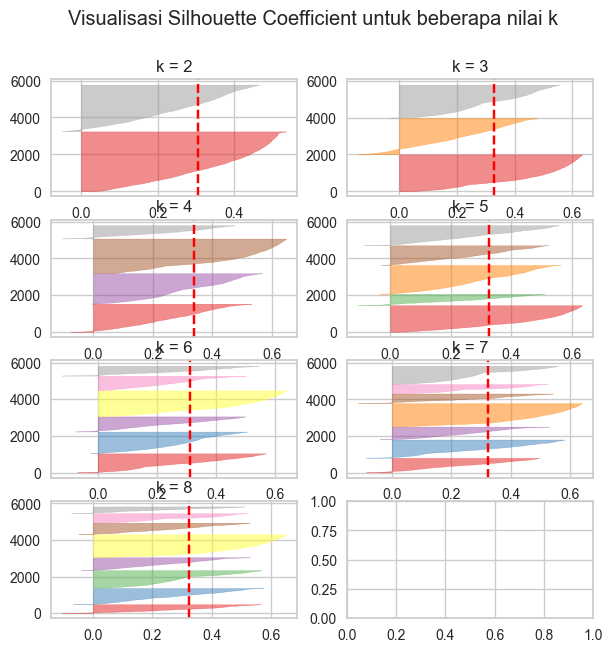

In [117]:
possible_k = range(2, 9)
for k in possible_k:
    clusterer = KMeans(n_clusters = k, n_init=10)

    cluster_labels = clusterer.fit_predict(clu_df)
    silhouette_avg = silhouette_score(clu_df, cluster_labels)
    print(f"Untuk k = {k}, rata-rata silhouette_coefficient adalah: {silhouette_avg}")

fig, ax = plt.subplots(4, 2, figsize=(7,7))
fig.suptitle("Visualisasi Silhouette Coefficient untuk beberapa nilai k")
for k in possible_k:
    clusterer = KMeans(n_clusters=k, n_init=10)

    q, mod = divmod(k, 2)
    ax[q-1][mod].set_title(f"k = {k}")
    visualizer = SilhouetteVisualizer(clusterer, ax = ax[q-1][mod])
    visualizer.fit(clu_df)

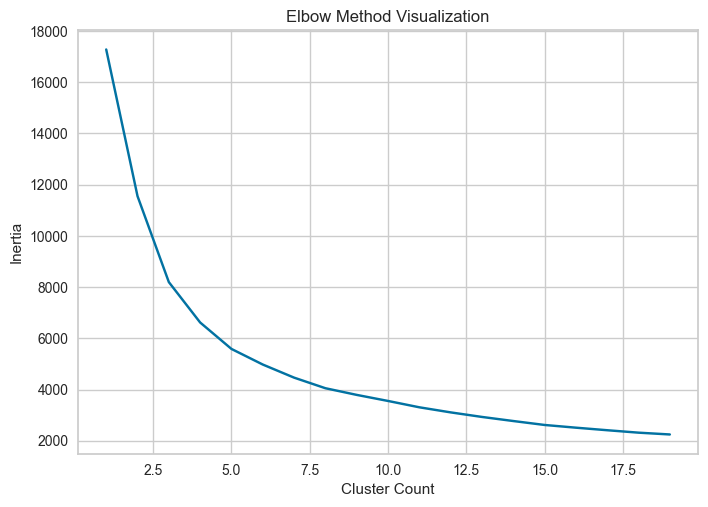

In [118]:
possible_k = range(1, 20)
inertia = []
for cluster in possible_k:
    km = KMeans(n_clusters=cluster, n_init=10)
    km = km.fit(clu_df)
    inertia.append(km.inertia_)

plt.plot(possible_k, inertia, 'bx-')
plt.xlabel('Cluster Count')
plt.ylabel('Inertia')
plt.title('Elbow Method Visualization')
plt.show()

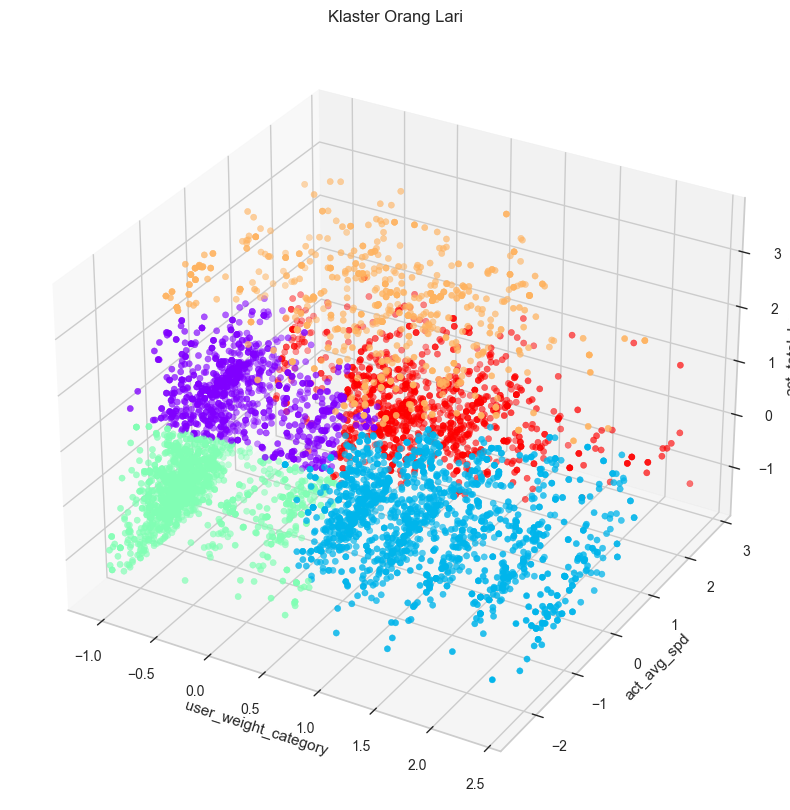

In [119]:
kmeans = KMeans(n_clusters=5, n_init=10)
cluster_pred = kmeans.fit_predict(clu_df)

df_with_clusters = pd.DataFrame(clu_df.copy())
df_with_clusters['cluster'] = cluster_pred

fig = plt.figure(figsize = (10, 10))
ax = plt.axes(projection="3d")

x = df_with_clusters['user_weight_category']
y = df_with_clusters['act_avg_spd']
z = df_with_clusters['act_total_km']
cluster = df_with_clusters['cluster']

ax.scatter(x, y, z, c = cluster, cmap = "rainbow")
plt.title("Klaster Orang Lari")
plt.grid(True)
ax.set_xlabel('user_weight_category')
ax.set_ylabel('act_avg_spd')
ax.set_zlabel('act_total_km')

plt.show()

# Kaggle : Time to put the models to the test

### 1. Classification

In [120]:
kaggle_cla = pd.read_csv('test_csl_cla_x.csv')
display(kaggle_cla.head())
display(kaggle_cla.info())
display(kaggle_cla.describe())

kaggle_cla_x = kaggle_cla.copy().drop(['id', 'user_id'], axis=1)

,user_age_group,user_id,attempt_date,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,25 to 34,258,2018-03-12,112,28.9,487,Starbucks to Majid,75 to 84 kg,Mittagsradfahrt,25.5,45.7,50.39,7128,7128,0,265
1,35 to 44,731,2016-11-02,190,20.3,840,King Street side,85 to 95 kg,Evening Ride,19.9,37.8,35.00,6338,6338,0,2473
2,35 to 44,1144,2018-06-22,55,23.1,1180,Al Fardoos to shellfish round about,65 to 74 kg,Morning Ride,24.0,81.0,108.01,16202,16202,0,1835
3,35 to 44,830,2015-01-31,222,21.9,643,Starbucks to Majid,75 to 84 kg,Morning Ride,20.7,36.0,21.79,3787,3787,0,865
4,35 to 44,340,2014-10-21,278,22.7,266,Headquarters Business Park,65 to 74 kg,تمرين مع أحمد سعيد,23.8,43.9,31.05,4699,4699,0,7404


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786 entries, 0 to 785
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        786 non-null    object 
 1   user_id               786 non-null    int64  
 2   attempt_date          786 non-null    object 
 3   smt_rank              786 non-null    int64  
 4   smt_avg_spd           786 non-null    float64
 5   smt_finish_seconds    786 non-null    int64  
 6   smt_name              786 non-null    object 
 7   user_weight_category  750 non-null    object 
 8   act_title             786 non-null    object 
 9   act_avg_spd           786 non-null    float64
 10  act_max_spd           786 non-null    float64
 11  act_total_km          786 non-null    float64
 12  act_moving_seconds    786 non-null    int64  
 13  act_total_seconds     786 non-null    int64  
 14  has_hr_data           786 non-null    int64  
 15  id                    7

None

,user_id,smt_rank,smt_avg_spd,smt_finish_seconds,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
count,786.000000,786.000000,786.000000,786.000000,786.000000,786.000000,786.000000,7.860000e+02,7.860000e+02,786.000000,786.000000
mean,784.875318,156.643766,27.233206,532.155216,23.060305,45.723664,43.474109,9.761720e+03,9.761720e+03,0.222646,3795.035623
std,532.306362,162.759149,8.746603,350.130835,5.646403,15.987585,34.365598,7.555210e+04,7.555210e+04,0.416288,2315.752606
min,1.000000,1.000000,2.500000,118.000000,0.100000,12.200000,4.950000,1.267000e+03,1.267000e+03,0.000000,0.000000
25%,340.250000,30.250000,21.600000,272.250000,19.100000,37.100000,24.327500,4.075250e+03,4.075250e+03,0.000000,1730.500000
50%,731.500000,92.000000,26.800000,467.000000,22.900000,42.500000,37.500000,5.689000e+03,5.689000e+03,0.000000,3685.000000
75%,1066.500000,251.000000,32.875000,679.750000,26.800000,49.000000,53.250000,8.161500e+03,8.161500e+03,0.000000,5817.250000
max,2249.000000,785.000000,63.500000,3175.000000,41.200000,178.900000,706.590000,2.110063e+06,2.110063e+06,1.000000,7851.000000


In [121]:
numeric_columns = kaggle_cla_x.select_dtypes(include=np.number).columns
kaggle_cla_x = cla_imputer.transform(kaggle_cla_x)

# Convert from array back to dataframe
kaggle_cla_x = pd.DataFrame(kaggle_cla_x, columns=cla_imputer.get_feature_names_out())
for col in numeric_columns:
    kaggle_cla_x[col] = kaggle_cla_x[col].convert_dtypes()

kaggle_cla_x.loc[:,'user_age_group'] = kaggle_cla_x['user_age_group'].map(age_group_mapping)
kaggle_cla_x.loc[:,'user_weight_category'] = kaggle_cla_x['user_weight_category'].map(weight_group_mapping)

kaggle_cla_x = kaggle_cla_x.drop(['act_title'], axis=1)

kaggle_cla_x.loc[:, 'attempt_date'] = pd.to_datetime(kaggle_cla_x['attempt_date'], errors="raise").dt.dayofweek

for col in ['user_weight_category', 'user_age_group', 'attempt_date']:
    kaggle_cla_x[col] = pd.to_numeric(kaggle_cla_x[col], errors="raise")

kaggle_cla_x = pd.get_dummies(kaggle_cla_x)
kaggle_cla_x = kaggle_cla_x.astype('float32')

In [122]:
kaggle_cla_pred = cla_model.predict(kaggle_cla_x)

kaggle_cla_map = {
    "female" :1, 
    "male" :2
}

kaggle_cla_result = pd.DataFrame({
    "id" : kaggle_cla["id"],
    "gender" : kaggle_cla_pred
})

kaggle_cla_result.loc[:, 'gender'] = kaggle_cla_result['gender'].map(kaggle_cla_map)

#kaggle_cla_result.to_csv("classification_csl_admission_result_bingchilling_adit.csv", index=False)

kaggle_cla_result

,id,gender
0,265,2
1,2473,2
2,1835,2
3,865,2
4,7404,2
...,...,...
781,1055,2
782,3322,2
783,5652,2
784,3131,2


### 2. Regression

In [123]:
kaggle_reg = pd.read_csv('test_csl_reg_x.csv')
display(kaggle_reg.head())
display(kaggle_reg.info())
display(kaggle_reg.describe())

kaggle_reg_x = kaggle_reg.copy().drop(['id', 'user_id'], axis=1)

,user_age_group,user_id,attempt_date,smt_rank,smt_avg_spd,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id,gender
0,25 to 34,564,2018-07-15,33,36.9,PRINCE SULTAN - ASSALAM TO FATIMA,65 to 74 kg,Night Ride,34.6,50.8,41.61,4326,4326,0,2699,male
1,25 to 34,323,2018-01-03,181,26.2,Starbucks to Majid,75 to 84 kg,احلى تمرين مع دراج جدة two hearts person bikin...,25.4,40.3,45.37,6427,6427,0,332,male
2,25 to 34,149,2019-07-19,3,56.0,Oghor 2 SailsIsland,54 kg and under,Afternoon Ride,22.6,85.3,78.45,12507,12507,0,3282,male
3,45 to 54,1027,2018-06-22,142,11.1,North Corniche,75 to 84 kg,Morning Ride,12.1,16.9,21.01,6254,6254,0,5891,male
4,35 to 44,823,2018-08-29,216,22.2,Starbucks to Majid,85 to 95 kg,تمرين جميل مع دراج جدة red heart,21.9,45.7,57.15,9398,9398,0,858,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787 entries, 0 to 786
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        787 non-null    object 
 1   user_id               787 non-null    int64  
 2   attempt_date          787 non-null    object 
 3   smt_rank              787 non-null    int64  
 4   smt_avg_spd           787 non-null    float64
 5   smt_name              787 non-null    object 
 6   user_weight_category  748 non-null    object 
 7   act_title             787 non-null    object 
 8   act_avg_spd           787 non-null    float64
 9   act_max_spd           787 non-null    float64
 10  act_total_km          787 non-null    float64
 11  act_moving_seconds    787 non-null    int64  
 12  act_total_seconds     787 non-null    int64  
 13  has_hr_data           787 non-null    int64  
 14  id                    787 non-null    int64  
 15  gender                7

None

,user_id,smt_rank,smt_avg_spd,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
count,787.000000,787.000000,787.000000,787.000000,787.000000,787.000000,7.870000e+02,7.870000e+02,787.000000,787.000000
mean,783.270648,171.344346,26.829098,22.733545,45.219187,41.596582,1.029166e+04,1.029166e+04,0.200762,3948.637865
std,536.982903,171.239783,8.405565,5.356886,15.778187,25.510661,1.045413e+05,1.045413e+05,0.400825,2293.120435
min,1.000000,1.000000,2.700000,0.100000,14.000000,3.540000,6.450000e+02,6.450000e+02,0.000000,17.000000
25%,328.500000,36.500000,21.500000,18.900000,37.400000,23.660000,4.099000e+03,4.099000e+03,0.000000,1937.500000
50%,715.000000,111.000000,26.200000,22.300000,42.100000,36.700000,5.769000e+03,5.769000e+03,0.000000,4012.000000
75%,1094.000000,268.500000,32.350000,26.300000,48.600000,51.670000,7.788000e+03,7.788000e+03,0.000000,5914.000000
max,2243.000000,798.000000,63.100000,52.600000,229.700000,313.550000,2.937143e+06,2.937143e+06,1.000000,7864.000000


In [124]:
column_to_move = kaggle_reg_x.pop('gender')
kaggle_reg_x.insert(2, "gender", column_to_move)


In [125]:
numeric_columns = kaggle_reg_x.select_dtypes(include=np.number).columns
kaggle_reg_x = reg_imputer.transform(kaggle_reg_x)
# Convert from array back to dataframe
kaggle_reg_x = pd.DataFrame(kaggle_reg_x, columns=reg_imputer.get_feature_names_out())
for col in numeric_columns:
    kaggle_reg_x[col] = kaggle_reg_x[col].convert_dtypes()

kaggle_reg_x.loc[:,'user_age_group'] = kaggle_reg_x['user_age_group'].map(age_group_mapping)
kaggle_reg_x.loc[:,'user_weight_category'] = kaggle_reg_x['user_weight_category'].map(weight_group_mapping)
kaggle_reg_x.loc[:,'gender'] = kaggle_reg_x['gender'].map(gender_mapping)

kaggle_reg_x = kaggle_reg_x.drop(['act_title'], axis=1)

kaggle_reg_x.loc[:, 'attempt_date'] = pd.to_datetime(kaggle_reg_x['attempt_date'], errors="raise").dt.dayofweek

for col in ['user_weight_category', 'gender', 'user_age_group', 'attempt_date']:
    kaggle_reg_x[col] = pd.to_numeric(kaggle_reg_x[col], errors="raise")

kaggle_reg_x = pd.get_dummies(kaggle_reg_x)
kaggle_reg_x = kaggle_reg_x.astype('float32')

In [126]:
kaggle_reg_pred = reg_model.predict(kaggle_reg_x)

kaggle_reg_result = pd.DataFrame({
    "id" : kaggle_reg["id"],
    "smt_finish_seconds" : kaggle_reg_pred
})

#kaggle_reg_result.to_csv("regression_csl_admission_result_bingchilling_adit.csv", index=False)

kaggle_reg_result

,id,smt_finish_seconds
0,2699,265.030603
1,332,538.103151
2,3282,158.430492
3,5891,1558.942421
4,858,634.972452
...,...,...
782,2726,302.878325
783,7350,251.925000
784,4370,391.394211
785,4979,538.175659
